In [234]:
#IMPORTS
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import matplotlib.pyplot as plt
import os

In [235]:
#LOAD DATASET
data_path = "house_prices.csv"
df = pd.read_csv(data_path)

df.head()

,SquareFootage,Bedrooms,Bathrooms,Price
0,1500,3,2.0,285000
1,2000,4,3.0,370000
2,1200,2,1.5,220000
3,1800,3,2.0,315000
4,2500,4,3.5,450000


In [236]:
#EDA
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SquareFootage  50 non-null     int64  
 1   Bedrooms       50 non-null     int64  
 2   Bathrooms      50 non-null     float64
 3   Price          50 non-null     int64  
dtypes: float64(1), int64(3)
memory usage: 1.7 KB


In [237]:
#FEATURES
X = df[['SquareFootage', 'Bedrooms', 'Bathrooms']]
y = df['Price']

In [238]:
#TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [239]:
#TRAIN MODEL
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 143.17,12294.96,11658.77]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['SquareFootage','Bedrooms','Bathrooms']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1689
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [240]:
#COEFFICIENTS
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 1688.7420841649873
Coefficients: [  143.17408701 12294.96338645 11658.76819373]


In [241]:
#PREDICTION
y_pred = model.predict(X_test)

In [242]:
#METRICS
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score:", metrics.r2_score(y_test, y_pred))

MAE: 1973.2864659590646
MSE: 8089864.892520797
RMSE: 2844.2687799363825
R2 Score: 0.9994116393432563


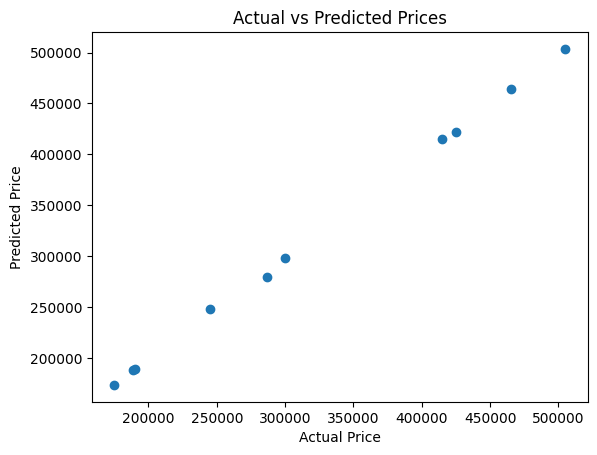

In [243]:
#VISUALIZATION
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

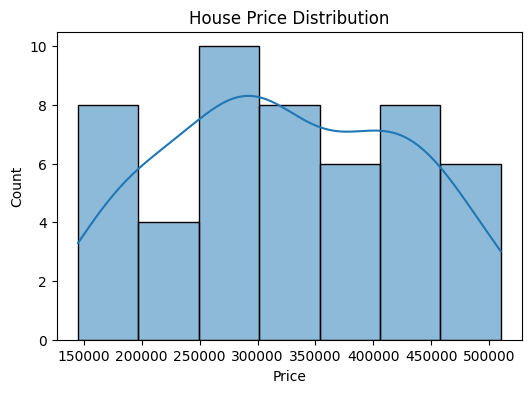

In [244]:
#PRICE DISTRIBUTION
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df['Price'], kde=True)
plt.title("House Price Distribution")
plt.show()

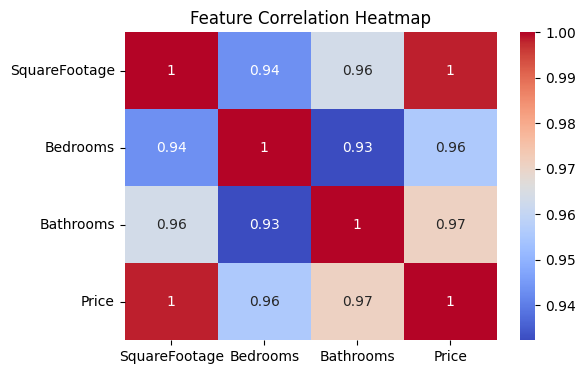

In [245]:
#CORRELATION HEATMAP
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

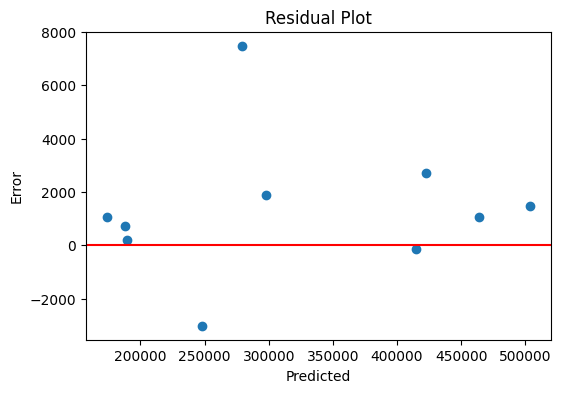

In [246]:
#RESIDUAL PLOT (ERROR ANALYSIS)
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Error")
plt.show()

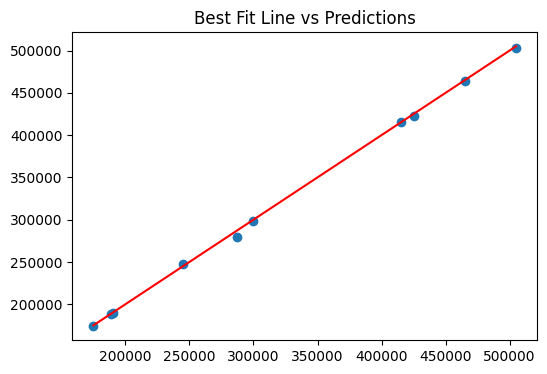

In [247]:
#LINEAR FIT VISUAL
plt.figure(figsize=(6,4))
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.scatter(y_test, y_pred)
plt.title("Best Fit Line vs Predictions")
plt.show()

In [248]:
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

In [249]:
width = 62

def line(left, right=""):
    text = f"{left} {right}".strip()
    return "║ " + text.ljust(width - 1) + "║"

print("╔" + "═" * width + "╗")
print("║" + "🏠 HOUSE PRICE PREDICTION-PROJECT SUMMARY".center(60)+"║")
print("╠" + "═" * width + "╣")

print(line(""))
print(line("Organisation  :", "SkillCraft Technology"))
print(line("Task          :", "Task 1 - Linear Regression"))
print(line(""))

print("╠" + "═" * width + "╣")

print(line("Dataset size  :", str(len(df))))
print(line("Features used :", "SquareFootage, Bedrooms, Bathrooms"))
print(line("Model         :", "Linear Regression (OLS)"))

print(line(""))

print("╠" + "═" * width + "╣")

def inr(x):
    return f"₹{x:,.2f}"

print(line("MAE           :", inr(mae)))
print(line("RMSE          :", inr(rmse)))
print(line("R² Score      :", f"{r2:.4f}"))

print(line(""))

print("╚" + "═" * width + "╝")

╔══════════════════════════════════════════════════════════════╗
║          🏠 HOUSE PRICE PREDICTION-PROJECT SUMMARY          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║ Organisation  : SkillCraft Technology                        ║
║ Task          : Task 1 - Linear Regression                   ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║ Dataset size  : 50                                           ║
║ Features used : SquareFootage, Bedrooms, Bathrooms           ║
║ Model         : Linear Regression (OLS)                      ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║ MAE           : ₹1,973.29                                    ║
║ RMSE          : ₹2,844.27                                    ║
║ R² Score      : 0.9994   